
Initial model dataset shape: (500, 6)
Dataset shape after light target outlier trimming: (429, 6)
Features used: ['Year_Index', 'Gas_Share', 'Oil_Share', 'Heat_Share', 'Chilled_Share', 'Gas_Share_Sq', 'Heat_Share_Sq', 'Gas_Heat', 'Heat_Cool_Diff']


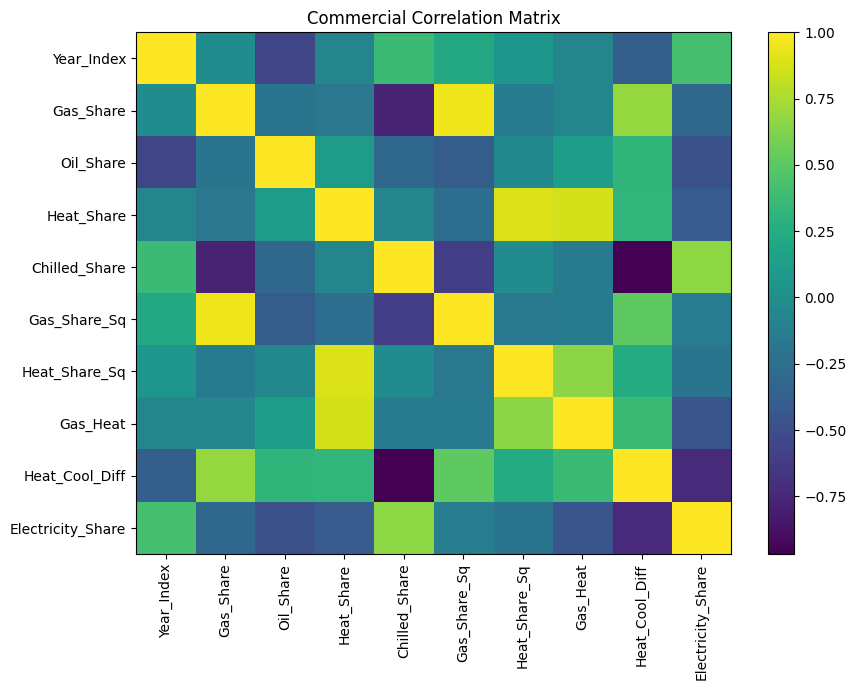


Correlation with Electricity_Share:
Electricity_Share    1.000000
Chilled_Share        0.662601
Year_Index           0.417122
Gas_Share_Sq        -0.134412
Heat_Share_Sq       -0.209326
Gas_Share           -0.299865
Heat_Share          -0.404407
Gas_Heat            -0.447723
Oil_Share           -0.480271
Heat_Cool_Diff      -0.730774
Name: Electricity_Share, dtype: float64

Commercial electricity share model results:
Features used: ['Year_Index', 'Gas_Share', 'Oil_Share', 'Heat_Share', 'Chilled_Share', 'Gas_Share_Sq', 'Heat_Share_Sq', 'Gas_Heat', 'Heat_Cool_Diff']
Training samples: 343
Testing samples: 86

Model performance:
MSE: 0.005342799390609747
RMSE: 0.07309445526583906
MAE: 0.05389247187466998
R^2: 0.7471025330552405

Baseline performance (predict mean):
MSE: 0.021191098596611987
RMSE: 0.14557162703154755
MAE: 0.09777551115041716
R^2: -0.0030650161184893054


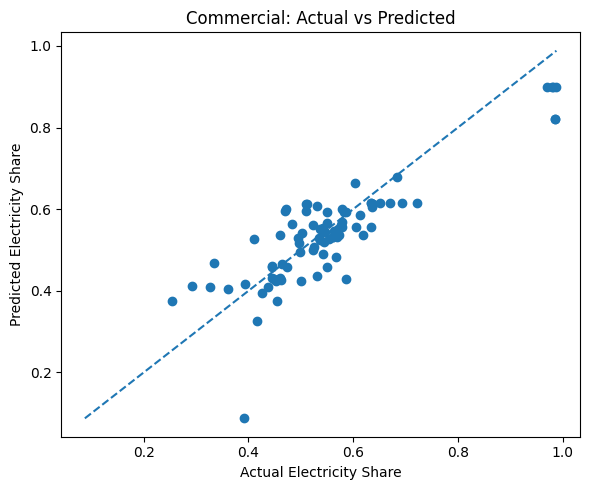

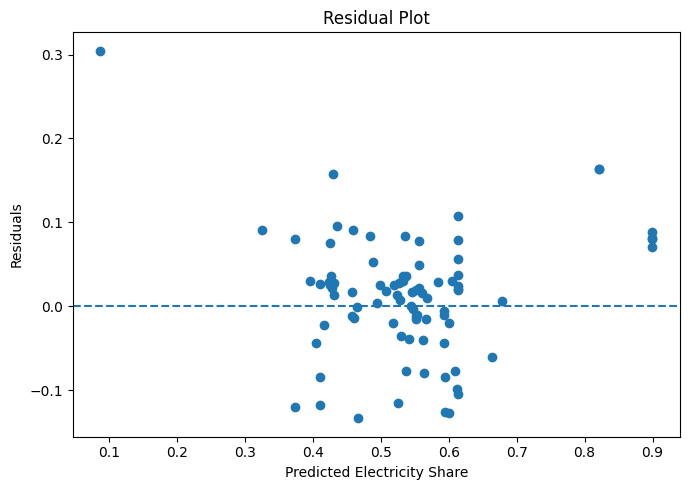

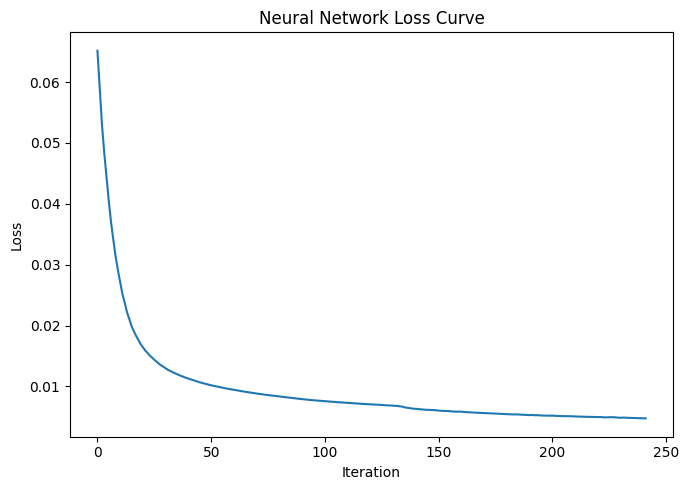

In [8]:
# Build energy features
energy_parts = [
    "Natural_Gas",
    "Fuel_Oil",
    "District_Heat",
    "District_Chilled_Water",
    "Propane"
]

present_energy_parts = [c for c in energy_parts if c in model_subset.columns]
if len(present_energy_parts) == 0:
    raise ValueError("No common energy source columns found.")

for col in present_energy_parts:
    model_subset[col] = model_subset[col].fillna(0)

if "Electricity" not in model_subset.columns:
    raise ValueError("No Electricity column found.")

model_subset = model_subset.dropna(subset=["Electricity", "Year_Index"]).copy()
model_subset = model_subset[model_subset["Electricity"] > 0].copy()

model_subset["Total_NonElectric_Energy"] = model_subset[present_energy_parts].sum(axis=1)
model_subset["Total_Energy_With_Electricity"] = (
    model_subset["Electricity"] + model_subset["Total_NonElectric_Energy"]
)

model_subset = model_subset[
    model_subset["Total_Energy_With_Electricity"] > 0
].copy()

# Target variable
model_subset["Electricity_Share"] = (
    model_subset["Electricity"] / model_subset["Total_Energy_With_Electricity"]
)

# Share-based features
if "Natural_Gas" in model_subset.columns:
    model_subset["Gas_Share"] = np.where(
        model_subset["Total_NonElectric_Energy"] > 0,
        model_subset["Natural_Gas"] / model_subset["Total_NonElectric_Energy"],
        0
    )

if "Fuel_Oil" in model_subset.columns:
    model_subset["Oil_Share"] = np.where(
        model_subset["Total_NonElectric_Energy"] > 0,
        model_subset["Fuel_Oil"] / model_subset["Total_NonElectric_Energy"],
        0
    )

if "District_Heat" in model_subset.columns:
    model_subset["Heat_Share"] = np.where(
        model_subset["Total_NonElectric_Energy"] > 0,
        model_subset["District_Heat"] / model_subset["Total_NonElectric_Energy"],
        0
    )

if "District_Chilled_Water" in model_subset.columns:
    model_subset["Chilled_Share"] = np.where(
        model_subset["Total_NonElectric_Energy"] > 0,
        model_subset["District_Chilled_Water"] / model_subset["Total_NonElectric_Energy"],
        0
    )

# Base feature set
candidate_features = [
    "Year_Index",
    "Gas_Share",
    "Oil_Share",
    "Heat_Share",
    "Chilled_Share"
]

available_features = [c for c in candidate_features if c in model_subset.columns]
model_data = model_subset[available_features + ["Electricity_Share"]].dropna().copy()

print("\nInitial model dataset shape:", model_data.shape)

# Light target outlier trimming using IQR on Electricity_Share
q1 = model_data["Electricity_Share"].quantile(0.25)
q3 = model_data["Electricity_Share"].quantile(0.75)
iqr = q3 - q1
lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = min(1, q3 + 1.5 * iqr)

model_data = model_data[
    (model_data["Electricity_Share"] >= lower_bound) &
    (model_data["Electricity_Share"] <= upper_bound)
].copy()

print("Dataset shape after light target outlier trimming:", model_data.shape)

# Add nonlinear / interaction features after trimming
if "Gas_Share" in model_data.columns:
    model_data["Gas_Share_Sq"] = model_data["Gas_Share"] ** 2

if "Heat_Share" in model_data.columns:
    model_data["Heat_Share_Sq"] = model_data["Heat_Share"] ** 2

if all(c in model_data.columns for c in ["Gas_Share", "Heat_Share"]):
    model_data["Gas_Heat"] = model_data["Gas_Share"] * model_data["Heat_Share"]

if all(c in model_data.columns for c in ["Heat_Share", "Chilled_Share"]):
    model_data["Heat_Cool_Diff"] = model_data["Heat_Share"] - model_data["Chilled_Share"]

# Final features
final_features = [
    "Year_Index",
    "Gas_Share",
    "Oil_Share",
    "Heat_Share",
    "Chilled_Share",
    "Gas_Share_Sq",
    "Heat_Share_Sq",
    "Gas_Heat",
    "Heat_Cool_Diff"
]
final_features = [c for c in final_features if c in model_data.columns]

print("Features used:", final_features)

# Correlation matrix
corr_cols = final_features + ["Electricity_Share"]
corr_matrix = model_data[corr_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Commercial Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation with Electricity_Share:")
print(corr_matrix["Electricity_Share"].sort_values(ascending=False))

# Train/test split
X = model_data[final_features]
y = model_data["Electricity_Share"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tuned neural network
model = MLPRegressor(
    hidden_layer_sizes=(12, 6),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=6000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred = np.clip(y_pred, 0, 1)

# Baseline prediction
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("\nCommercial electricity share model results:")
print("Features used:", final_features)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nModel performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)

print("\nBaseline performance (predict mean):")
print("MSE:", baseline_mse)
print("RMSE:", baseline_rmse)
print("MAE:", baseline_mae)
print("R^2:", baseline_r2)

# Actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Electricity Share")
plt.ylabel("Predicted Electricity Share")
plt.title("Commercial: Actual vs Predicted")
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Electricity Share")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

# Loss curve
if hasattr(model, "loss_curve_"):
    plt.figure(figsize=(7, 5))
    plt.plot(model.loss_curve_)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Neural Network Loss Curve")
    plt.tight_layout()
    plt.show()